# ESOL Baseline Comparison (7 Modelle)

Dieses Notebook vergleicht auf **demselben Scaffold-Split** sieben Baselines fuer ESOL (Regression):
1. RF auf Graph-Features (aus denselben Atom-/Bond-Features wie `smiles_to_graph` aggregiert)
2. RF auf RDKit-Deskriptoren
3. ChebNet von Scratch
4. ChebNet mit Foundation-Checkpoint (Pretrained Init, 2-stage FT)
5. Standard-SEG (Regression)
6. SEG: Foundation-ChebNet direkt kopiert -> end-to-end Fine-Tuning
7. SEG: Foundation-ChebNet erst auf ESOL (Cheb) finetunen -> dann in SEG -> end-to-end Fine-Tuning

In [10]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors

import deepchem as dc
from sklearn.ensemble import RandomForestRegressor

RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'models').exists()), here)
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from models.cheb_predictor import ChebPredictor, ChebPredictorConfig
from models.seg_predictor import SEGPredictor, SEGPredictorConfig
from utils.embedding_cache import EfficientEmbeddingCache
from utils.molecular_graph import smiles_to_graph

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

print(f'Workspace root: {workspace_root}')
print(f'Device: {device}')

Workspace root: C:\Users\robsc\Home\Dev\molfusion2
Device: cuda


In [11]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=np.float32).reshape(-1)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mae = float(np.mean(np.abs(y_pred - y_true)))
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0
    return {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
    }

In [12]:
tasks, datasets, _ = dc.molnet.load_delaney(featurizer='ECFP', splitter='scaffold')
train_dc, valid_dc, test_dc = datasets

train_smiles = list(train_dc.ids)
valid_smiles = list(valid_dc.ids)
test_smiles = list(test_dc.ids)

train_y_arr = train_dc.y.reshape(-1).astype(np.float32)
valid_y_arr = valid_dc.y.reshape(-1).astype(np.float32)
test_y_arr = test_dc.y.reshape(-1).astype(np.float32)

train_y = train_y_arr.tolist()
valid_y = valid_y_arr.tolist()

print(f'ESOL sizes -> train={len(train_smiles)}, val={len(valid_smiles)}, test={len(test_smiles)}')
print(f'Train mean/std: {np.mean(train_y_arr):.4f} / {np.std(train_y_arr):.4f}')

ESOL sizes -> train=902, val=113, test=113
Train mean/std: 0.0000 / 1.0000


In [13]:
def _impute_with_train_median(train_X, valid_X, test_X):
    med = np.nanmedian(train_X, axis=0)
    med = np.where(np.isfinite(med), med, 0.0).astype(np.float32)

    def _imp(X):
        X = np.asarray(X, dtype=np.float32)
        mask = ~np.isfinite(X)
        if mask.any():
            X = X.copy()
            X[mask] = np.take(med, np.where(mask)[1])
        return X

    return _imp(train_X), _imp(valid_X), _imp(test_X)

def graph_feature_vector_from_smiles(smiles):
    g = smiles_to_graph(smiles, add_hydrogens=False)
    X = np.asarray(g.X, dtype=np.float32)
    ew = np.asarray(g.edge_weight, dtype=np.float32)

    x_sum = X.sum(axis=0)
    x_mean = X.mean(axis=0)
    x_std = X.std(axis=0)

    n_nodes = float(g.n_nodes)
    n_edges_undir = float(g.edge_index.shape[1] // 2)
    ew_mean = float(ew.mean()) if ew.size else 0.0
    ew_std = float(ew.std()) if ew.size else 0.0
    ew_sum = float(ew.sum()) if ew.size else 0.0

    return np.concatenate([
        x_sum, x_mean, x_std,
        np.array([n_nodes, n_edges_undir, ew_mean, ew_std, ew_sum], dtype=np.float32),
    ])

def build_graph_feature_matrix(smiles_list):
    rows = []
    for smi in smiles_list:
        try:
            rows.append(graph_feature_vector_from_smiles(smi))
        except Exception:
            rows.append(np.full((89,), np.nan, dtype=np.float32))
    return np.vstack(rows).astype(np.float32)

def rdkit_descriptor_matrix(smiles_list):
    desc_names = [name for name, _ in Descriptors.descList]
    n_desc = len(desc_names)
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append(np.full((n_desc,), np.nan, dtype=np.float32))
            continue
        all_descs = Descriptors.CalcMolDescriptors(mol)
        row = []
        for name in desc_names:
            try:
                row.append(float(all_descs.get(name, np.nan)))
            except Exception:
                row.append(np.nan)
        rows.append(np.asarray(row, dtype=np.float32))
    return np.vstack(rows).astype(np.float32), desc_names

In [14]:
# --- Baseline 1: RF auf Graph-Features ---
g_train = build_graph_feature_matrix(train_smiles)
g_valid = build_graph_feature_matrix(valid_smiles)
g_test = build_graph_feature_matrix(test_smiles)
g_train, g_valid, g_test = _impute_with_train_median(g_train, g_valid, g_test)

rf_graph = RandomForestRegressor(
    n_estimators=1200,
    max_features='sqrt',
    random_state=seed,
    n_jobs=-1,
)
rf_graph.fit(g_train, train_y_arr)
rf_graph_test_pred = rf_graph.predict(g_test)
rf_graph_metrics = regression_metrics(test_y_arr, rf_graph_test_pred)

# --- Baseline 2: RF auf RDKit-Deskriptoren ---
d_train, desc_names = rdkit_descriptor_matrix(train_smiles)
d_valid, _ = rdkit_descriptor_matrix(valid_smiles)
d_test, _ = rdkit_descriptor_matrix(test_smiles)
d_train, d_valid, d_test = _impute_with_train_median(d_train, d_valid, d_test)

rf_desc = RandomForestRegressor(
    n_estimators=1200,
    max_features='sqrt',
    random_state=seed,
    n_jobs=-1,
)
rf_desc.fit(d_train, train_y_arr)
rf_desc_test_pred = rf_desc.predict(d_test)
rf_desc_metrics = regression_metrics(test_y_arr, rf_desc_test_pred)

print('RF Graph metrics:', rf_graph_metrics)
print('RF RDKit metrics:', rf_desc_metrics)

RF Graph metrics: {'rmse': 0.5337101221084595, 'mae': 0.4077802300453186, 'r2': 0.729196586371134}
RF RDKit metrics: {'rmse': 0.5071890950202942, 'mae': 0.36326467990875244, 'r2': 0.755441310265137}


In [15]:
CHEB_CFG = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'sum',
}

VANILLA_FIT_KWARGS = {
    'batch_size': 64,
    'num_epochs': 200,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'patience': 30,
}

CHEB_FIT_KWARGS = {
    'batch_size': 64,
    'frozen_epochs': 40,
    'unfreeze_epochs': 160,
    'head_lr': 5e-4,
    'encoder_lr': 5e-5,
    'weight_decay': 1e-1,
    'patience': 30,
}

SEG_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'sum',
    'set2set_processing_steps': 6,
    'fusion': 'cross_mha',
    'fusion_dim': 64,
    'fusion_n_heads': 8,
    'text_proj_init': 'xavier',
    'text_proj_init_gain': 0.1,
    'freeze_text_proj': True,
    'dropout': 0.3,
    'fusion_dropout': 0.3,
    'head_dropout': 0.5,
    'weight_decay': 1e-1,
    'head_type': 'mlp',
    'head_hidden_dim': 32,
    'learning_rate': 5e-4,
    'batch_size': 32,
    'num_epochs': 200,
    'patience': 20,
    'scheduler': 'cosine',
    'scheduler_patience': 5,
    'scheduler_factor': 0.5,
    'min_lr': 1e-6,
    'grad_clip': None,
}

SEG_CHEB_INIT_FIT_KWARGS = {**SEG_FIT_KWARGS, **{
    'hidden_channels': CHEB_CFG['hidden_channels'],
    'K': CHEB_CFG['K'],
    'num_layers': CHEB_CFG['num_layers'],
    'pool': CHEB_CFG['pool'],
    'learning_rate': 2e-4,
}}

def make_esol_config():
    return ChebPredictorConfig(
        task='regression',
        hidden_channels=CHEB_CFG['hidden_channels'],
        K=CHEB_CFG['K'],
        num_layers=CHEB_CFG['num_layers'],
        pool=CHEB_CFG['pool'],
        dropout=0.3,
        lambda_max=2.0,
        add_hydrogens=False,
        head_hidden_dim=32,
        head_dropout=0.5,
    )

def make_seg_config(text_embedding_dim):
    return SEGPredictorConfig(
        task='regression',
        hidden_channels=SEG_FIT_KWARGS['hidden_channels'],
        K=SEG_FIT_KWARGS['K'],
        num_layers=SEG_FIT_KWARGS['num_layers'],
        dropout=SEG_FIT_KWARGS['dropout'],
        pool=SEG_FIT_KWARGS['pool'],
        set2set_processing_steps=SEG_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        text_projection_dim=SEG_FIT_KWARGS['fusion_dim'],
        text_proj_init=SEG_FIT_KWARGS['text_proj_init'],
        text_proj_init_gain=SEG_FIT_KWARGS['text_proj_init_gain'],
        freeze_text_proj=SEG_FIT_KWARGS['freeze_text_proj'],
        fusion=SEG_FIT_KWARGS['fusion'],
        fusion_dim=SEG_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=SEG_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=SEG_FIT_KWARGS['fusion_dropout'],
        head_type=SEG_FIT_KWARGS['head_type'],
        head_hidden_dim=SEG_FIT_KWARGS['head_hidden_dim'],
        head_dropout=SEG_FIT_KWARGS['head_dropout'],
    )

def make_seg_pretrained_graph_config(text_embedding_dim):
    return SEGPredictorConfig(
        task='regression',
        hidden_channels=SEG_CHEB_INIT_FIT_KWARGS['hidden_channels'],
        K=SEG_CHEB_INIT_FIT_KWARGS['K'],
        num_layers=SEG_CHEB_INIT_FIT_KWARGS['num_layers'],
        dropout=SEG_CHEB_INIT_FIT_KWARGS['dropout'],
        pool=SEG_CHEB_INIT_FIT_KWARGS['pool'],
        set2set_processing_steps=SEG_CHEB_INIT_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        text_projection_dim=SEG_CHEB_INIT_FIT_KWARGS['fusion_dim'],
        text_proj_init=SEG_CHEB_INIT_FIT_KWARGS['text_proj_init'],
        text_proj_init_gain=SEG_CHEB_INIT_FIT_KWARGS['text_proj_init_gain'],
        freeze_text_proj=SEG_CHEB_INIT_FIT_KWARGS['freeze_text_proj'],
        fusion=SEG_CHEB_INIT_FIT_KWARGS['fusion'],
        fusion_dim=SEG_CHEB_INIT_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=SEG_CHEB_INIT_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=SEG_CHEB_INIT_FIT_KWARGS['fusion_dropout'],
        head_type=SEG_CHEB_INIT_FIT_KWARGS['head_type'],
        head_hidden_dim=SEG_CHEB_INIT_FIT_KWARGS['head_hidden_dim'],
        head_dropout=SEG_CHEB_INIT_FIT_KWARGS['head_dropout'],
    )

def load_encoder_from_pretraining(predictor, pretrain_checkpoint_path):
    ckpt = torch.load(pretrain_checkpoint_path, map_location=predictor.device, weights_only=False)
    ckpt_cfg = ckpt.get('cheb_cfg', {})
    required_keys = ('hidden_channels', 'K', 'num_layers', 'pool')
    mismatches = []
    for k in required_keys:
        if k in ckpt_cfg and ckpt_cfg[k] != CHEB_CFG[k]:
            mismatches.append((k, ckpt_cfg[k], CHEB_CFG[k]))
    if mismatches:
        mismatch_msg = '; '.join([f"{k}: ckpt={a} current={b}" for (k, a, b) in mismatches])
        raise RuntimeError(f'Checkpoint encoder config mismatch: {mismatch_msg}')

    pre_state = ckpt['model_state_dict']
    enc_state = {k.replace('encoder.', '', 1): v for k, v in pre_state.items() if k.startswith('encoder.')}
    predictor._encoder.load_state_dict(enc_state, strict=True)

    pool_state = {k.replace('pooling.', '', 1): v for k, v in pre_state.items() if k.startswith('pooling.')}
    if pool_state:
        try:
            predictor._pooling.load_state_dict(pool_state, strict=True)
            print('Loaded pooling weights from pretraining checkpoint.')
        except Exception as exc:
            print(f'Pooling weights not loaded (shape or module mismatch): {exc}')

def make_cheb_backbone_from_pretraining(pretrain_checkpoint_path, sample_smiles):
    cheb_backbone = ChebPredictor(config=make_esol_config(), device=str(device))
    _, in_channels = cheb_backbone._precompute_graphs(sample_smiles, verbose=False)
    cheb_backbone._in_channels = in_channels
    cheb_backbone._build_model()
    load_encoder_from_pretraining(cheb_backbone, pretrain_checkpoint_path)
    cheb_backbone._is_fitted = True
    return cheb_backbone

def fit_two_stage(
    predictor,
    train_smiles, train_y,
    valid_smiles, valid_y,
    *,
    seed=42,
    batch_size=32,
    frozen_epochs=40,
    unfreeze_epochs=160,
    head_lr=5e-4,
    encoder_lr=5e-5,
    weight_decay=1e-1,
    patience=30,
    pretrained_ckpt=None,
    verbose=True,
):
    train_graphs, in_channels = predictor._precompute_graphs(train_smiles, verbose=verbose)
    valid_graphs, _ = predictor._precompute_graphs(valid_smiles, verbose=verbose)
    predictor._in_channels = in_channels
    predictor._build_model()

    if pretrained_ckpt is not None:
        load_encoder_from_pretraining(predictor, pretrained_ckpt)

    y_train = np.asarray(train_y, dtype=np.float32)
    y_valid = np.asarray(valid_y, dtype=np.float32)
    train_idx = np.arange(len(train_smiles))
    valid_idx = list(range(len(valid_smiles)))
    loss_fn = nn.MSELoss() if predictor.config.task == 'regression' else nn.BCELoss()

    rng = np.random.default_rng(seed)
    history = {'train_loss': [], 'val_loss': [], 'stage': []}
    best_val = float('inf')
    best_state = None
    stale = 0

    for p in predictor._encoder.parameters():
        p.requires_grad = False
    for p in predictor._pooling.parameters():
        p.requires_grad = False
    for p in predictor._head.parameters():
        p.requires_grad = True

    opt_head = torch.optim.Adam(
        list(predictor._head.parameters()),
        lr=head_lr,
        weight_decay=weight_decay,
    )

    for epoch in range(1, frozen_epochs + 1):
        tr = predictor._train_epoch(train_graphs, y_train, train_idx, batch_size, opt_head, loss_fn, rng)
        vl = predictor._evaluate(valid_graphs, y_valid, valid_idx, batch_size, loss_fn)
        history['train_loss'].append(float(tr))
        history['val_loss'].append(float(vl))
        history['stage'].append('frozen')

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(f'[frozen] epoch {epoch:03d} | train_loss={tr:.6f} | val_loss={vl:.6f}')

        if vl < best_val:
            best_val = float(vl)
            best_state = predictor._get_state_dict()
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                if verbose:
                    print(f'Early stop in frozen stage at epoch {epoch}')
                break

    for p in predictor._encoder.parameters():
        p.requires_grad = True
    for p in predictor._pooling.parameters():
        p.requires_grad = True
    for p in predictor._head.parameters():
        p.requires_grad = True

    opt_full = torch.optim.Adam(
        [
            {'params': list(predictor._encoder.parameters()) + list(predictor._pooling.parameters()), 'lr': encoder_lr},
            {'params': list(predictor._head.parameters()), 'lr': head_lr},
        ],
        weight_decay=weight_decay,
    )

    stale = 0
    for epoch in range(1, unfreeze_epochs + 1):
        tr = predictor._train_epoch(train_graphs, y_train, train_idx, batch_size, opt_full, loss_fn, rng)
        vl = predictor._evaluate(valid_graphs, y_valid, valid_idx, batch_size, loss_fn)
        history['train_loss'].append(float(tr))
        history['val_loss'].append(float(vl))
        history['stage'].append('unfreeze')

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(f'[unfreeze] epoch {epoch:03d} | train_loss={tr:.6f} | val_loss={vl:.6f}')

        if vl < best_val:
            best_val = float(vl)
            best_state = predictor._get_state_dict()
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                if verbose:
                    print(f'Early stop in unfreeze stage at epoch {epoch}')
                break

    if best_state is not None:
        predictor._load_state_dict(best_state)
    predictor._is_fitted = True

    return history, best_val

SEG_TRANSFER_FIT_KWARGS = {
    'batch_size': 64,
    'frozen_epochs': 30,
    'unfreeze_epochs': 170,
    'fusion_lr': 2e-4,
    'encoder_lr': 5e-5,
    'weight_decay': 1e-1,
    'patience': 30,
}

def fit_seg_two_stage(
    predictor,
    train_smiles, train_y,
    valid_smiles, valid_y,
    *,
    train_text_embeddings,
    valid_text_embeddings,
    seed=42,
    batch_size=64,
    frozen_epochs=30,
    unfreeze_epochs=170,
    fusion_lr=2e-4,
    encoder_lr=5e-5,
    weight_decay=1e-1,
    patience=30,
    verbose=True,
):
    if predictor._encoder is None or predictor._fusion is None or predictor._head is None:
        train_graphs, in_channels = predictor._precompute_graphs(train_smiles, verbose=verbose)
        valid_graphs, _ = predictor._precompute_graphs(valid_smiles, verbose=verbose)
        predictor._in_channels = in_channels
        predictor._build_model()
    else:
        train_graphs, _ = predictor._precompute_graphs(train_smiles, verbose=verbose)
        valid_graphs, _ = predictor._precompute_graphs(valid_smiles, verbose=verbose)

    if isinstance(train_text_embeddings, torch.Tensor):
        train_text_emb = train_text_embeddings.detach().cpu().numpy()
    else:
        train_text_emb = np.asarray(train_text_embeddings, dtype=np.float32)

    if isinstance(valid_text_embeddings, torch.Tensor):
        valid_text_emb = valid_text_embeddings.detach().cpu().numpy()
    else:
        valid_text_emb = np.asarray(valid_text_embeddings, dtype=np.float32)

    y_train = np.asarray(train_y, dtype=np.float32)
    y_valid = np.asarray(valid_y, dtype=np.float32)
    train_idx = np.arange(len(train_smiles))
    valid_idx = list(range(len(valid_smiles)))

    is_multilabel = (predictor.config.num_tasks > 1)
    if predictor.config.task == 'classification':
        loss_fn = nn.BCELoss(reduction='none') if is_multilabel else nn.BCELoss()
    else:
        loss_fn = nn.MSELoss(reduction='none') if is_multilabel else nn.MSELoss()

    rng = np.random.default_rng(seed)
    history = {'train_loss': [], 'val_loss': [], 'stage': []}
    best_val = float('inf')
    best_state = None
    stale = 0

    for p in predictor._encoder.parameters():
        p.requires_grad = False
    for p in predictor._pooling.parameters():
        p.requires_grad = False
    for p in predictor._fusion.parameters():
        p.requires_grad = True
    for p in predictor._head.parameters():
        p.requires_grad = True

    stage1_params = list(predictor._fusion.parameters()) + list(predictor._head.parameters())
    if predictor._text_proj is not None:
        for p in predictor._text_proj.parameters():
            p.requires_grad = True
        stage1_params += list(predictor._text_proj.parameters())

    opt_stage1 = torch.optim.AdamW(stage1_params, lr=fusion_lr, weight_decay=weight_decay)

    for epoch in range(1, frozen_epochs + 1):
        tr = predictor._train_epoch(
            train_graphs, train_text_emb, y_train, train_idx, batch_size, opt_stage1, loss_fn, rng,
            is_multilabel=is_multilabel,
        )
        vl = predictor._evaluate(
            valid_graphs, valid_text_emb, y_valid, valid_idx, batch_size, loss_fn,
            is_multilabel=is_multilabel,
        )
        history['train_loss'].append(float(tr))
        history['val_loss'].append(float(vl))
        history['stage'].append('frozen')

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(f'[seg frozen] epoch {epoch:03d} | train={tr:.6f} | val={vl:.6f}')

        if vl < best_val:
            best_val = float(vl)
            best_state = predictor._get_state_dict()
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                if verbose:
                    print(f'SEG early stop in frozen stage at epoch {epoch}')
                break

    for p in predictor._encoder.parameters():
        p.requires_grad = True
    for p in predictor._pooling.parameters():
        p.requires_grad = True
    for p in predictor._fusion.parameters():
        p.requires_grad = True
    for p in predictor._head.parameters():
        p.requires_grad = True

    graph_params = list(predictor._encoder.parameters()) + list(predictor._pooling.parameters())
    fusion_head_params = list(predictor._fusion.parameters()) + list(predictor._head.parameters())
    if predictor._text_proj is not None:
        fusion_head_params += list(predictor._text_proj.parameters())

    opt_stage2 = torch.optim.AdamW(
        [
            {'params': graph_params, 'lr': encoder_lr},
            {'params': fusion_head_params, 'lr': fusion_lr},
        ],
        weight_decay=weight_decay,
    )

    stale = 0
    for epoch in range(1, unfreeze_epochs + 1):
        tr = predictor._train_epoch(
            train_graphs, train_text_emb, y_train, train_idx, batch_size, opt_stage2, loss_fn, rng,
            is_multilabel=is_multilabel,
        )
        vl = predictor._evaluate(
            valid_graphs, valid_text_emb, y_valid, valid_idx, batch_size, loss_fn,
            is_multilabel=is_multilabel,
        )
        history['train_loss'].append(float(tr))
        history['val_loss'].append(float(vl))
        history['stage'].append('unfreeze')

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(f'[seg unfreeze] epoch {epoch:03d} | train={tr:.6f} | val={vl:.6f}')

        if vl < best_val:
            best_val = float(vl)
            best_state = predictor._get_state_dict()
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                if verbose:
                    print(f'SEG early stop in unfreeze stage at epoch {epoch}')
                break

    if best_state is not None:
        predictor._load_state_dict(best_state)
    predictor._is_fitted = True

    return history, best_val

REQUIRED_PRETRAIN_STAGE = 'stage2_descriptor'

def resolve_config_specific_checkpoint(workspace_root, cheb_cfg, required_stage=REQUIRED_PRETRAIN_STAGE):
    ckpt_dir = workspace_root / 'cache' / 'chemeleon_pretraining'
    if not ckpt_dir.exists():
        raise FileNotFoundError(f'Checkpoint directory not found: {ckpt_dir}')

    patterns = [
        (
            f"cheb_foundation_2stage__h{cheb_cfg['hidden_channels']}__"
            f"L{cheb_cfg['num_layers']}__"
            f"K{cheb_cfg['K']}__*.pt"
        ),
        (
            f"cheb_foundation__h{cheb_cfg['hidden_channels']}__"
            f"L{cheb_cfg['num_layers']}__"
            f"K{cheb_cfg['K']}__*.pt"
        ),
    ]

    candidates = []
    for pat in patterns:
        for p in ckpt_dir.glob(pat):
            if p.name == 'cheb_foundation_pretrain.pt' or '__fallback__' in p.name:
                continue
            candidates.append(p)

    uniq = []
    seen = set()
    for p in candidates:
        s = str(p.resolve())
        if s not in seen:
            uniq.append(p)
            seen.add(s)
    candidates = uniq

    ranked = []
    for p in candidates:
        score = float('inf')
        stage_ok = False
        stage_val = None
        try:
            payload = torch.load(p, map_location='cpu', weights_only=False)
            if isinstance(payload, dict):
                raw = payload.get('best_val_masked_mse', None)
                if raw is not None:
                    score = float(raw)
                stage_val = payload.get('pretraining_stage', None)
                if required_stage is None:
                    stage_ok = True
                else:
                    stage_ok = (stage_val == required_stage)
        except Exception:
            pass

        ranked.append((0 if stage_ok else 1, score, -p.stat().st_mtime, p, stage_val))

    if ranked:
        ranked.sort(key=lambda t: (t[0], t[1], t[2]))
        stage_priority, best_score, _, best_path, best_stage = ranked[0]
        if required_stage is not None and stage_priority != 0:
            print(
                f"Warning: no checkpoint with pretraining_stage='{required_stage}' found; "
                "falling back to best available config-matching checkpoint."
            )
        if np.isfinite(best_score):
            print(f"Checkpoint selection: best pretrain val_masked_mse={best_score:.6f}")
        else:
            print('Checkpoint selection: no best_val_masked_mse metadata found; using newest matching file')
        print(f"Checkpoint stage metadata: {best_stage}")
        return best_path

    alias = ckpt_dir / 'cheb_foundation_pretrain.pt'
    if alias.exists():
        payload = torch.load(alias, map_location='cpu', weights_only=False)
        alias_stage = payload.get('pretraining_stage', None) if isinstance(payload, dict) else None
        if required_stage is not None and alias_stage != required_stage:
            raise RuntimeError(
                f"Alias checkpoint exists but pretraining_stage={alias_stage!r} does not match "
                f"required stage {required_stage!r}."
            )
        print('Checkpoint selection: using latest alias fallback')
        print(f"Checkpoint stage metadata: {alias_stage}")
        return alias

    raise FileNotFoundError(
        f'No matching config-specific checkpoint found in {ckpt_dir} for required stage {required_stage!r}'
    )

In [16]:
# Embeddings laden (ESOL task)
emb_dir = workspace_root / 'cache' / 'cot_embeddings'
npz_path = emb_dir / 'solubility_fast_text_embeddings_compact.npz'
if not npz_path.exists():
    raise FileNotFoundError(f'SEG embedding cache not found: {npz_path}')

seg_cache = EfficientEmbeddingCache.load(npz_path)
all_smiles = train_smiles + valid_smiles + test_smiles
all_emb = torch.from_numpy(seg_cache.get_batch(all_smiles)).float()
n_train = len(train_smiles)
n_valid = len(valid_smiles)
train_emb = all_emb[:n_train]
valid_emb = all_emb[n_train:n_train + n_valid]
test_emb = all_emb[n_train + n_valid:]

# --- Baseline 3: ChebNet from scratch ---
cheb_scratch = ChebPredictor(config=make_esol_config(), device=str(device))
scratch_hist = cheb_scratch.fit(
    train_smiles,
    train_y,
    val_smiles=valid_smiles,
    val_labels=valid_y,
    num_epochs=VANILLA_FIT_KWARGS['num_epochs'],
    batch_size=VANILLA_FIT_KWARGS['batch_size'],
    learning_rate=VANILLA_FIT_KWARGS['learning_rate'],
    weight_decay=VANILLA_FIT_KWARGS['weight_decay'],
    patience=VANILLA_FIT_KWARGS['patience'],
    seed=seed,
    verbose=True,
)
cheb_scratch_best_val = float(np.min(scratch_hist['val_loss']))
cheb_scratch_test_pred = cheb_scratch.predict_batch(test_smiles)
cheb_scratch_metrics = regression_metrics(test_y_arr, cheb_scratch_test_pred)

# --- Baseline 4: Pretrained encoder + echtes Fine-Tuning (2-stage) ---
pretrained_ckpt = resolve_config_specific_checkpoint(workspace_root, CHEB_CFG)
print('Using pretrained checkpoint:', pretrained_ckpt.resolve())

cheb_pretrained = ChebPredictor(config=make_esol_config(), device=str(device))
pre_hist, cheb_pretrained_best_val = fit_two_stage(
    cheb_pretrained,
    train_smiles,
    train_y,
    valid_smiles,
    valid_y,
    seed=seed,
    batch_size=CHEB_FIT_KWARGS['batch_size'],
    frozen_epochs=CHEB_FIT_KWARGS['frozen_epochs'],
    unfreeze_epochs=CHEB_FIT_KWARGS['unfreeze_epochs'],
    head_lr=CHEB_FIT_KWARGS['head_lr'],
    encoder_lr=CHEB_FIT_KWARGS['encoder_lr'],
    weight_decay=CHEB_FIT_KWARGS['weight_decay'],
    patience=CHEB_FIT_KWARGS['patience'],
    pretrained_ckpt=pretrained_ckpt,
    verbose=True,
)
cheb_pretrained_test_pred = cheb_pretrained.predict_batch(test_smiles)
cheb_pretrained_metrics = regression_metrics(test_y_arr, cheb_pretrained_test_pred)

# --- Baseline 5: Standard SEG ---
seg = SEGPredictor(config=make_seg_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
seg_hist = seg.fit(
    smiles_list=train_smiles,
    labels=train_y,
    val_smiles=valid_smiles,
    val_labels=valid_y,
    text_embeddings=train_emb,
    val_text_embeddings=valid_emb,
    num_epochs=SEG_FIT_KWARGS['num_epochs'],
    batch_size=SEG_FIT_KWARGS['batch_size'],
    learning_rate=SEG_FIT_KWARGS['learning_rate'],
    weight_decay=SEG_FIT_KWARGS['weight_decay'],
    patience=SEG_FIT_KWARGS['patience'],
    scheduler=SEG_FIT_KWARGS['scheduler'],
    scheduler_patience=SEG_FIT_KWARGS['scheduler_patience'],
    scheduler_factor=SEG_FIT_KWARGS['scheduler_factor'],
    min_lr=SEG_FIT_KWARGS['min_lr'],
    grad_clip=SEG_FIT_KWARGS['grad_clip'],
    seed=seed,
    verbose=True,
)
seg_best_val = float(np.min(seg_hist['val_loss']))
seg_test_pred = seg.predict_batch(test_smiles, text_embeddings=test_emb)
seg_metrics = regression_metrics(test_y_arr, seg_test_pred)

# --- Baseline 6: Option 1 | Foundation-ChebNet -> SEG -> 2-stage Fine-Tuning ---
cheb_foundation_backbone = make_cheb_backbone_from_pretraining(pretrained_ckpt, train_smiles)
seg_foundation_e2e = SEGPredictor(
    config=make_seg_pretrained_graph_config(text_embedding_dim=all_emb.shape[1]),
    device=str(device),
)
seg_foundation_e2e.init_from_cheb(cheb_foundation_backbone)
seg_foundation_e2e_hist, seg_foundation_e2e_best_val = fit_seg_two_stage(
    seg_foundation_e2e,
    train_smiles,
    train_y,
    valid_smiles,
    valid_y,
    train_text_embeddings=train_emb,
    valid_text_embeddings=valid_emb,
    seed=seed,
    batch_size=SEG_TRANSFER_FIT_KWARGS['batch_size'],
    frozen_epochs=SEG_TRANSFER_FIT_KWARGS['frozen_epochs'],
    unfreeze_epochs=SEG_TRANSFER_FIT_KWARGS['unfreeze_epochs'],
    fusion_lr=SEG_TRANSFER_FIT_KWARGS['fusion_lr'],
    encoder_lr=SEG_TRANSFER_FIT_KWARGS['encoder_lr'],
    weight_decay=SEG_TRANSFER_FIT_KWARGS['weight_decay'],
    patience=SEG_TRANSFER_FIT_KWARGS['patience'],
    verbose=True,
)
seg_foundation_e2e_test_pred = seg_foundation_e2e.predict_batch(test_smiles, text_embeddings=test_emb)
seg_foundation_e2e_metrics = regression_metrics(test_y_arr, seg_foundation_e2e_test_pred)

# --- Baseline 7: Option 2 | Foundation -> Cheb ESOL FT -> SEG -> 2-stage Fine-Tuning ---
seg_esol_adapted_e2e = SEGPredictor(
    config=make_seg_pretrained_graph_config(text_embedding_dim=all_emb.shape[1]),
    device=str(device),
)
seg_esol_adapted_e2e.init_from_cheb(cheb_pretrained)
seg_esol_adapted_e2e_hist, seg_esol_adapted_e2e_best_val = fit_seg_two_stage(
    seg_esol_adapted_e2e,
    train_smiles,
    train_y,
    valid_smiles,
    valid_y,
    train_text_embeddings=train_emb,
    valid_text_embeddings=valid_emb,
    seed=seed,
    batch_size=SEG_TRANSFER_FIT_KWARGS['batch_size'],
    frozen_epochs=SEG_TRANSFER_FIT_KWARGS['frozen_epochs'],
    unfreeze_epochs=SEG_TRANSFER_FIT_KWARGS['unfreeze_epochs'],
    fusion_lr=SEG_TRANSFER_FIT_KWARGS['fusion_lr'],
    encoder_lr=SEG_TRANSFER_FIT_KWARGS['encoder_lr'],
    weight_decay=SEG_TRANSFER_FIT_KWARGS['weight_decay'],
    patience=SEG_TRANSFER_FIT_KWARGS['patience'],
    verbose=True,
)
seg_esol_adapted_e2e_test_pred = seg_esol_adapted_e2e.predict_batch(test_smiles, text_embeddings=test_emb)
seg_esol_adapted_e2e_metrics = regression_metrics(test_y_arr, seg_esol_adapted_e2e_test_pred)

Loading embeddings from solubility_fast_text_embeddings_compact.npz...
  Loaded 1128 entries, dim=3072
  Memory mode: mapped
Pre-computing molecular graphs for 902 molecules...
Pre-computed 902/902 valid graphs
Pre-computing molecular graphs for 113 molecules...
Pre-computed 113/113 valid graphs
Training ChebPredictor on 902 molecules...
Task: regression
Validation set: 113 molecules
Epoch 001 | Train Loss: 0.9029 | Val Loss: 0.6214
Epoch 005 | Train Loss: 0.4802 | Val Loss: 0.3384
Epoch 010 | Train Loss: 0.3227 | Val Loss: 0.4168
Epoch 015 | Train Loss: 0.2324 | Val Loss: 0.3098
Epoch 020 | Train Loss: 0.1927 | Val Loss: 0.2610
Epoch 025 | Train Loss: 0.1789 | Val Loss: 0.2573
Epoch 030 | Train Loss: 0.1671 | Val Loss: 0.2856
Epoch 035 | Train Loss: 0.1647 | Val Loss: 0.2789
Epoch 040 | Train Loss: 0.1628 | Val Loss: 0.2509
Epoch 045 | Train Loss: 0.1538 | Val Loss: 0.2705
Epoch 050 | Train Loss: 0.1523 | Val Loss: 0.2618
Epoch 055 | Train Loss: 0.2019 | Val Loss: 0.2239
Epoch 060 | T

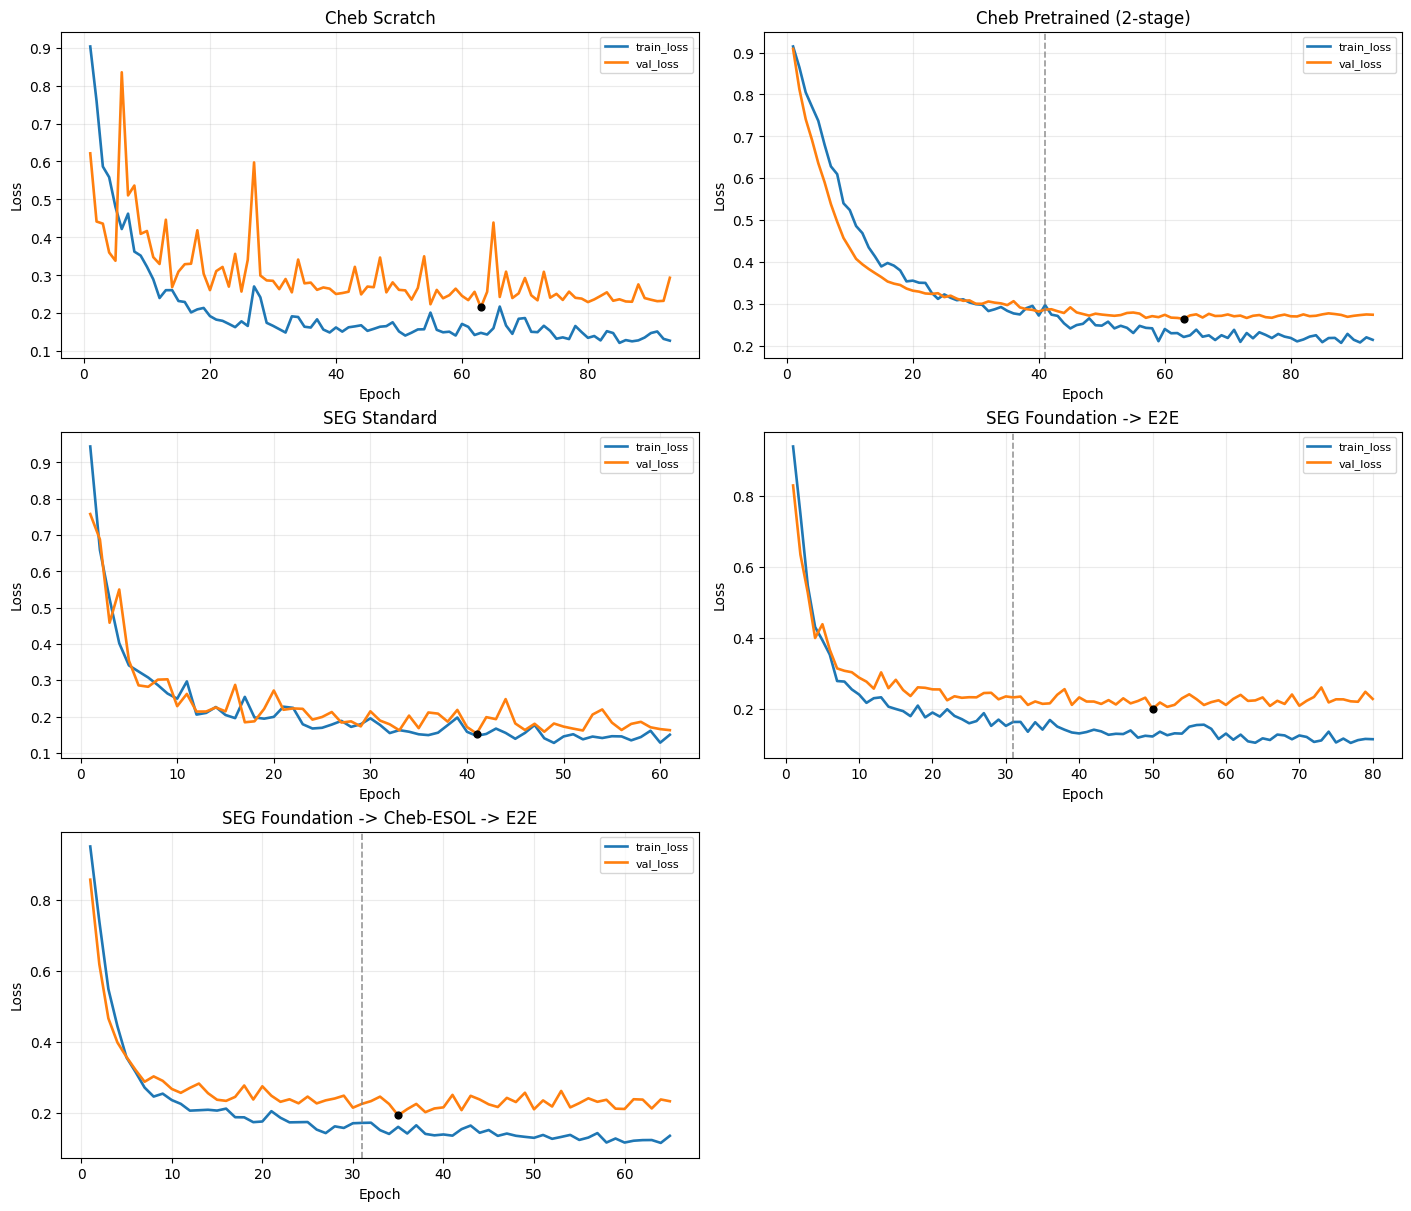

,model,best_val_loss,rmse,mae,r2
0,seg_standard,0.153442,0.391942,0.316238,0.853955
1,cheb_scratch,0.215431,0.441793,0.349581,0.814442
2,seg_esol_adapted_e2e,0.192158,0.472602,0.372795,0.787659
3,cheb_pretrained,0.264139,0.482665,0.390328,0.778519
4,seg_foundation_e2e,0.200388,0.490464,0.395599,0.771305
5,rf_rdkit_descriptors,NaN,0.507189,0.363265,0.755441
6,rf_graph_features,NaN,0.533710,0.407780,0.729197


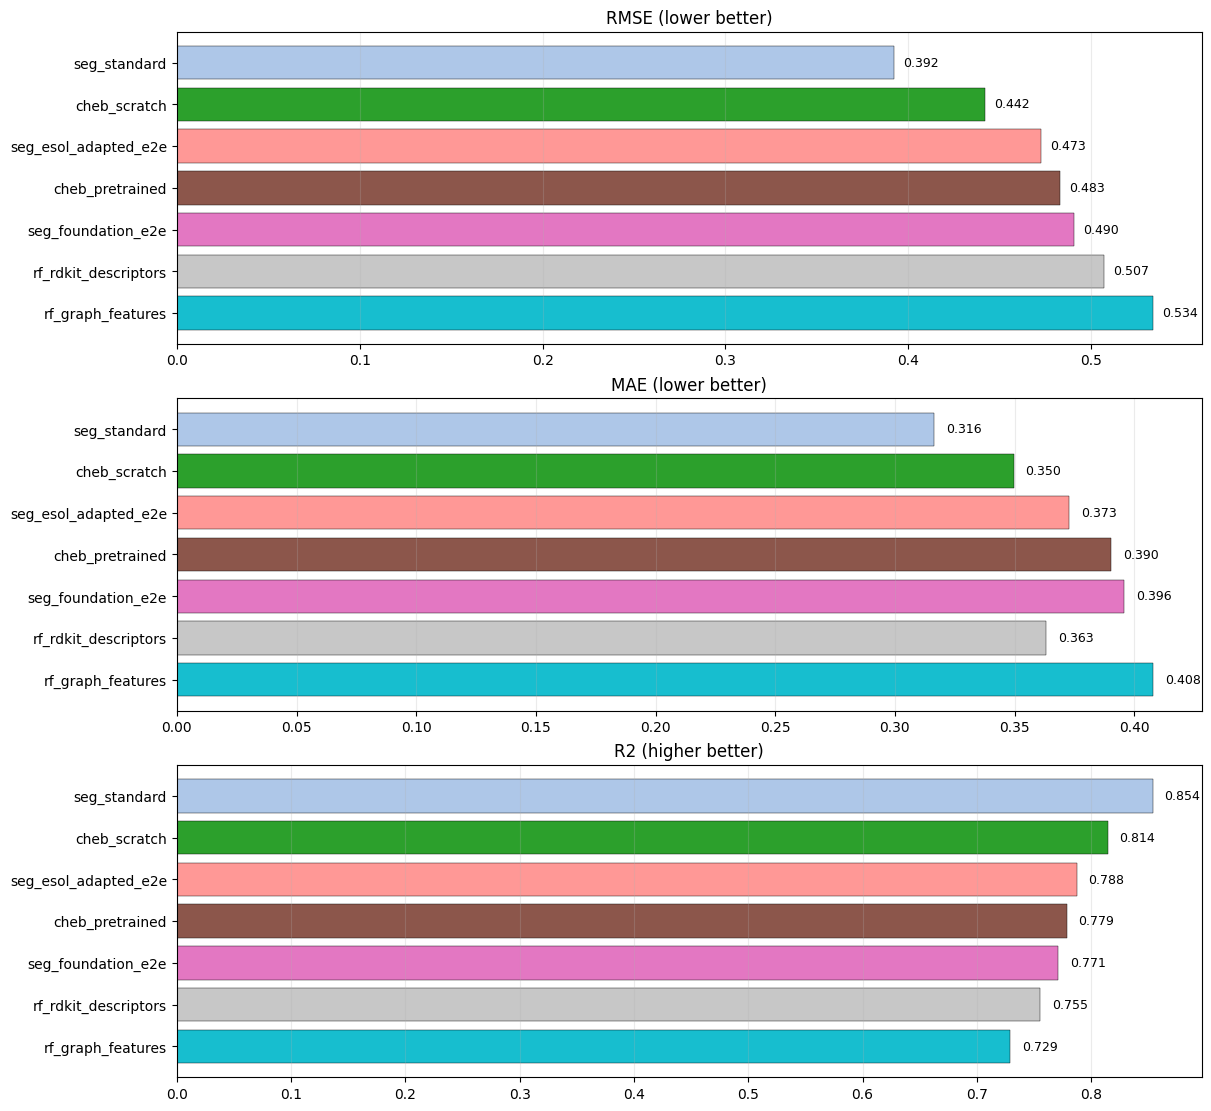

Saved comparison CSV to: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\esol_baseline_comparison.csv


In [17]:
def _plot_history(ax, history, title, *, stage_key='stage'):
    train_loss = np.asarray(history.get('train_loss', []), dtype=np.float32)
    val_loss = np.asarray(history.get('val_loss', []), dtype=np.float32)
    epochs = np.arange(1, len(train_loss) + 1)

    if len(train_loss) == 0:
        ax.text(0.5, 0.5, 'No history available', ha='center', va='center')
        ax.set_title(title)
        ax.set_axis_off()
        return

    ax.plot(epochs, train_loss, label='train_loss', linewidth=1.9)
    if len(val_loss) == len(train_loss):
        ax.plot(epochs, val_loss, label='val_loss', linewidth=1.9)
        best_ep = int(np.nanargmin(val_loss)) + 1
        best_val = float(val_loss[best_ep - 1])
        ax.scatter([best_ep], [best_val], color='black', s=24, zorder=3)

    stages = history.get(stage_key, None)
    if isinstance(stages, (list, tuple)) and len(stages) == len(train_loss):
        if 'unfreeze' in stages:
            transition_epoch = int(stages.index('unfreeze')) + 1
            ax.axvline(transition_epoch, linestyle='--', linewidth=1.2, alpha=0.8, color='tab:gray')

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(alpha=0.25)
    ax.legend(loc='best', fontsize=8)

fig, axes = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.flatten()
plot_items = [
    ('Cheb Scratch', scratch_hist),
    ('Cheb Pretrained (2-stage)', pre_hist),
    ('SEG Standard', seg_hist),
    ('SEG Foundation -> E2E', seg_foundation_e2e_hist),
    ('SEG Foundation -> Cheb-ESOL -> E2E', seg_esol_adapted_e2e_hist),
]
for i, (name, hist) in enumerate(plot_items):
    _plot_history(axes[i], hist, name)
for j in range(len(plot_items), len(axes)):
    axes[j].set_axis_off()
plt.show()

comparison_df = pd.DataFrame([
    {'model': 'rf_graph_features', 'best_val_loss': np.nan, **rf_graph_metrics},
    {'model': 'rf_rdkit_descriptors', 'best_val_loss': np.nan, **rf_desc_metrics},
    {'model': 'cheb_scratch', 'best_val_loss': cheb_scratch_best_val, **cheb_scratch_metrics},
    {'model': 'cheb_pretrained', 'best_val_loss': cheb_pretrained_best_val, **cheb_pretrained_metrics},
    {'model': 'seg_standard', 'best_val_loss': seg_best_val, **seg_metrics},
    {'model': 'seg_foundation_e2e', 'best_val_loss': seg_foundation_e2e_best_val, **seg_foundation_e2e_metrics},
    {'model': 'seg_esol_adapted_e2e', 'best_val_loss': seg_esol_adapted_e2e_best_val, **seg_esol_adapted_e2e_metrics},
])
comparison_df = comparison_df.sort_values('rmse', ascending=True).reset_index(drop=True)
display(comparison_df)

metrics_to_plot = ['rmse', 'mae', 'r2']
titles = ['RMSE (lower better)', 'MAE (lower better)', 'R2 (higher better)']
palette = plt.cm.tab20(np.linspace(0.08, 0.92, len(comparison_df)))

fig, axes = plt.subplots(3, 1, figsize=(12, 11), constrained_layout=True)
for ax, metric_name, title in zip(axes, metrics_to_plot, titles):
    values = comparison_df[metric_name].values
    y = np.arange(len(comparison_df))
    bars = ax.barh(y, values, color=palette, edgecolor='black', linewidth=0.3)
    ax.set_yticks(y)
    ax.set_yticklabels(comparison_df['model'])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)
    for bar, v in zip(bars, values):
        ax.text(v + (0.005 if metric_name != 'r2' else 0.01), bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center', fontsize=9)
plt.show()

out_csv = workspace_root / 'benchmarking' / 'results' / 'esol_baseline_comparison.csv'
comparison_df.to_csv(out_csv, index=False)
print(f'Saved comparison CSV to: {out_csv}')

## Multi-Seed Vergleich (6 Seeds)

Diese Sektion fuehrt alle 7 Baselines fuer mehrere Seeds aus und aggregiert RMSE/MAE/R2 (Mittelwert, Std, 95%-CI).

Multi-seed setup: [42, 113, 271, 777, 1337, 2025]
[1/6] Running seed 42 ...
✓ Copied encoder & pooling from ChebPredictor
  Encoder: 3 layers, hidden=128
  Pooling: sum
✓ Copied encoder & pooling from ChebPredictor
  Encoder: 3 layers, hidden=128
  Pooling: sum
                  model      rmse       mae        r2
0          seg_standard  0.387486  0.308018  0.857257
1          cheb_scratch  0.441467  0.349157  0.814716
2  seg_esol_adapted_e2e  0.459477  0.365100  0.799289
[2/6] Running seed 113 ...
✓ Copied encoder & pooling from ChebPredictor
  Encoder: 3 layers, hidden=128
  Pooling: sum
✓ Copied encoder & pooling from ChebPredictor
  Encoder: 3 layers, hidden=128
  Pooling: sum
                model      rmse       mae        r2
0        seg_standard  0.418159  0.334208  0.833764
1        cheb_scratch  0.465594  0.374218  0.793910
2  seg_foundation_e2e  0.468434  0.369865  0.791388
[3/6] Running seed 271 ...
✓ Copied encoder & pooling from ChebPredictor
  Encoder: 3 layers, hidden=

,seed,model,best_val_loss,rmse,mae,r2
0,42,rf_graph_features,NaN,0.533710,0.407780,0.729197
1,42,rf_rdkit_descriptors,NaN,0.507189,0.363265,0.755441
2,42,cheb_scratch,0.215133,0.441467,0.349157,0.814716
3,42,cheb_pretrained,0.264139,0.482665,0.390328,0.778519
4,42,seg_standard,0.152033,0.387486,0.308018,0.857257


Collected rows: 42


,model,n_runs,best_val_loss_mean,best_val_loss_std,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,rmse_sem,rmse_ci95,mae_sem,mae_ci95,r2_sem,r2_ci95
0,seg_standard,6,0.154721,0.004737,0.401803,0.012886,0.323637,0.012300,0.846382,0.009844,0.005261,0.010311,0.005021,0.009842,0.004019,0.007877
1,cheb_scratch,6,0.210908,0.006231,0.454881,0.011608,0.359551,0.010192,0.803178,0.009989,0.004739,0.009289,0.004161,0.008155,0.004078,0.007993
2,seg_esol_adapted_e2e,6,0.205995,0.006697,0.467989,0.014633,0.370733,0.008880,0.791614,0.013028,0.005974,0.011709,0.003625,0.007105,0.005319,0.010425
3,seg_foundation_e2e,6,0.209817,0.005595,0.471362,0.008850,0.372882,0.009084,0.788710,0.007959,0.003613,0.007081,0.003708,0.007269,0.003249,0.006369
4,cheb_pretrained,6,0.265917,0.001795,0.488109,0.003152,0.394618,0.003474,0.773487,0.002919,0.001287,0.002522,0.001418,0.002780,0.001192,0.002336
5,rf_rdkit_descriptors,6,NaN,NaN,0.507106,0.002943,0.360749,0.002208,0.755514,0.002842,0.001202,0.002355,0.000901,0.001767,0.001160,0.002274
6,rf_graph_features,6,NaN,NaN,0.534843,0.002527,0.407640,0.002316,0.728041,0.002565,0.001031,0.002022,0.000946,0.001854,0.001047,0.002052


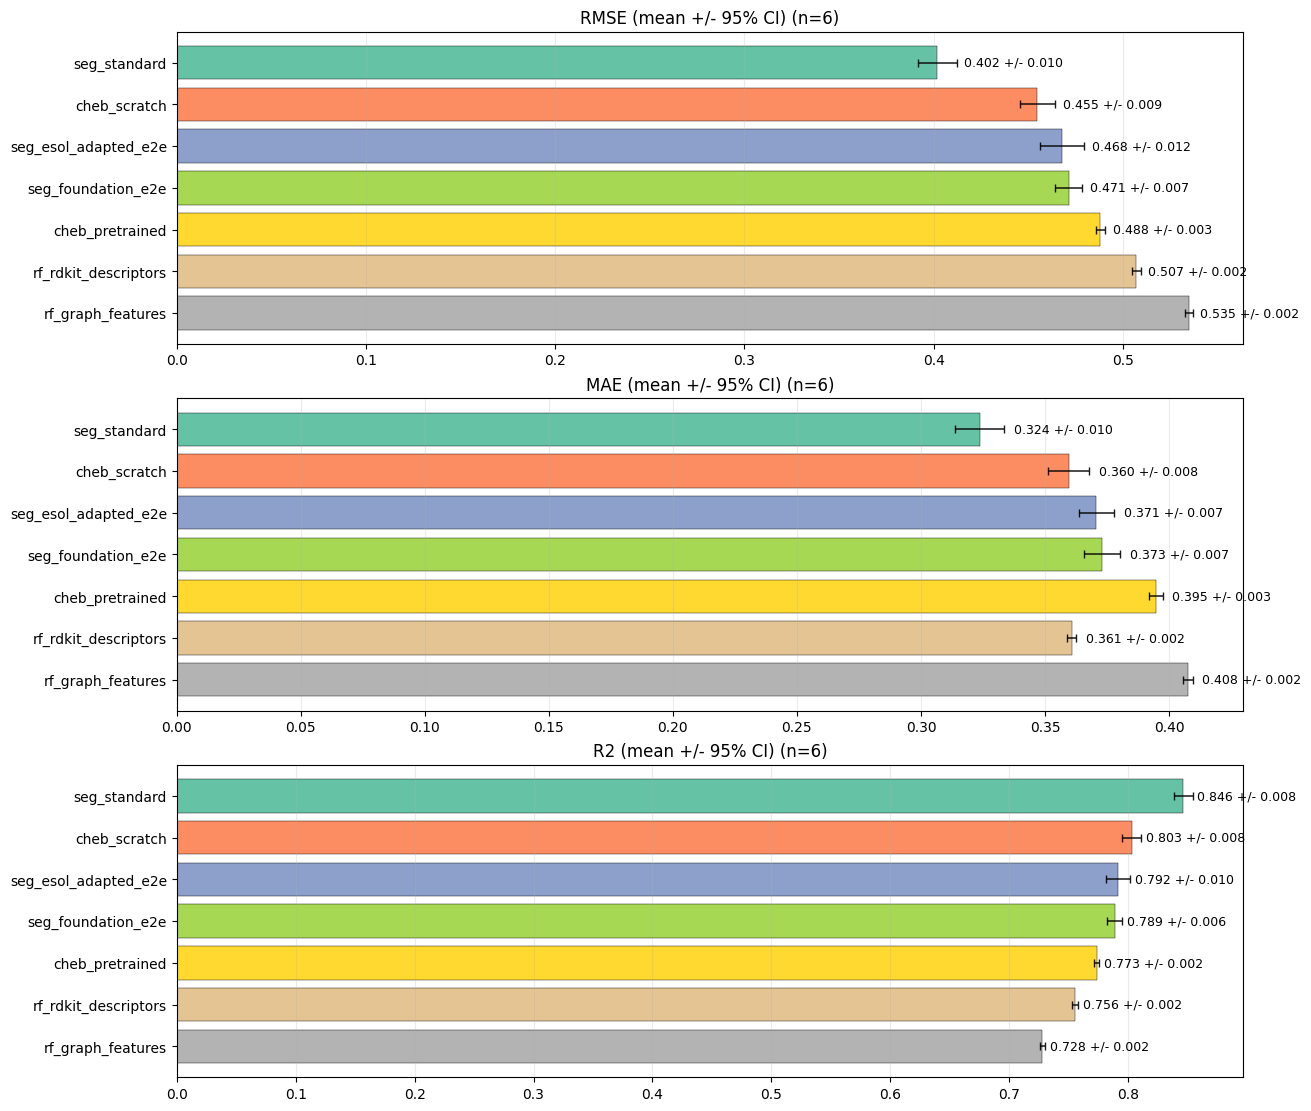

Saved multi-seed raw CSV: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\esol_baseline_comparison_multiseed_raw.csv
Saved multi-seed summary CSV: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\esol_baseline_comparison_multiseed_summary.csv


In [18]:
import random
import time

MULTI_SEEDS = [42, 113, 271, 777, 1337, 2025]
print('Multi-seed setup:', MULTI_SEEDS)

def _set_all_seeds(s):
    random.seed(int(s))
    np.random.seed(int(s))
    torch.manual_seed(int(s))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(s))

def run_all_baselines_for_seed(seed_i, verbose=False):
    _set_all_seeds(seed_i)
    t0 = time.time()

    rf_graph_i = RandomForestRegressor(
        n_estimators=1200,
        max_features='sqrt',
        random_state=int(seed_i),
        n_jobs=-1,
    )
    rf_graph_i.fit(g_train, train_y_arr)
    rf_graph_pred_i = rf_graph_i.predict(g_test)
    rf_graph_metrics_i = regression_metrics(test_y_arr, rf_graph_pred_i)

    rf_desc_i = RandomForestRegressor(
        n_estimators=1200,
        max_features='sqrt',
        random_state=int(seed_i),
        n_jobs=-1,
    )
    rf_desc_i.fit(d_train, train_y_arr)
    rf_desc_pred_i = rf_desc_i.predict(d_test)
    rf_desc_metrics_i = regression_metrics(test_y_arr, rf_desc_pred_i)

    cheb_scratch_i = ChebPredictor(config=make_esol_config(), device=str(device))
    scratch_hist_i = cheb_scratch_i.fit(
        train_smiles, train_y,
        val_smiles=valid_smiles, val_labels=valid_y,
        num_epochs=VANILLA_FIT_KWARGS['num_epochs'],
        batch_size=VANILLA_FIT_KWARGS['batch_size'],
        learning_rate=VANILLA_FIT_KWARGS['learning_rate'],
        weight_decay=VANILLA_FIT_KWARGS['weight_decay'],
        patience=VANILLA_FIT_KWARGS['patience'],
        seed=int(seed_i),
        verbose=verbose,
    )
    cheb_scratch_best_val_i = float(np.min(scratch_hist_i['val_loss']))
    cheb_scratch_pred_i = cheb_scratch_i.predict_batch(test_smiles)
    cheb_scratch_metrics_i = regression_metrics(test_y_arr, cheb_scratch_pred_i)

    cheb_pretrained_i = ChebPredictor(config=make_esol_config(), device=str(device))
    pre_hist_i, cheb_pretrained_best_val_i = fit_two_stage(
        cheb_pretrained_i,
        train_smiles, train_y, valid_smiles, valid_y,
        seed=int(seed_i),
        batch_size=CHEB_FIT_KWARGS['batch_size'],
        frozen_epochs=CHEB_FIT_KWARGS['frozen_epochs'],
        unfreeze_epochs=CHEB_FIT_KWARGS['unfreeze_epochs'],
        head_lr=CHEB_FIT_KWARGS['head_lr'],
        encoder_lr=CHEB_FIT_KWARGS['encoder_lr'],
        weight_decay=CHEB_FIT_KWARGS['weight_decay'],
        patience=CHEB_FIT_KWARGS['patience'],
        pretrained_ckpt=pretrained_ckpt,
        verbose=verbose,
    )
    cheb_pretrained_pred_i = cheb_pretrained_i.predict_batch(test_smiles)
    cheb_pretrained_metrics_i = regression_metrics(test_y_arr, cheb_pretrained_pred_i)

    seg_i = SEGPredictor(config=make_seg_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
    seg_hist_i = seg_i.fit(
        smiles_list=train_smiles, labels=train_y,
        val_smiles=valid_smiles, val_labels=valid_y,
        text_embeddings=train_emb, val_text_embeddings=valid_emb,
        num_epochs=SEG_FIT_KWARGS['num_epochs'],
        batch_size=SEG_FIT_KWARGS['batch_size'],
        learning_rate=SEG_FIT_KWARGS['learning_rate'],
        weight_decay=SEG_FIT_KWARGS['weight_decay'],
        patience=SEG_FIT_KWARGS['patience'],
        scheduler=SEG_FIT_KWARGS['scheduler'],
        scheduler_patience=SEG_FIT_KWARGS['scheduler_patience'],
        scheduler_factor=SEG_FIT_KWARGS['scheduler_factor'],
        min_lr=SEG_FIT_KWARGS['min_lr'],
        grad_clip=SEG_FIT_KWARGS['grad_clip'],
        seed=int(seed_i),
        verbose=verbose,
    )
    seg_best_val_i = float(np.min(seg_hist_i['val_loss']))
    seg_pred_i = seg_i.predict_batch(test_smiles, text_embeddings=test_emb)
    seg_metrics_i = regression_metrics(test_y_arr, seg_pred_i)

    cheb_foundation_backbone_i = make_cheb_backbone_from_pretraining(pretrained_ckpt, train_smiles)
    seg_foundation_e2e_i = SEGPredictor(
        config=make_seg_pretrained_graph_config(text_embedding_dim=all_emb.shape[1]),
        device=str(device),
    )
    seg_foundation_e2e_i.init_from_cheb(cheb_foundation_backbone_i)
    seg_foundation_e2e_hist_i, seg_foundation_e2e_best_val_i = fit_seg_two_stage(
        seg_foundation_e2e_i,
        train_smiles,
        train_y,
        valid_smiles,
        valid_y,
        train_text_embeddings=train_emb,
        valid_text_embeddings=valid_emb,
        seed=int(seed_i),
        batch_size=SEG_TRANSFER_FIT_KWARGS['batch_size'],
        frozen_epochs=SEG_TRANSFER_FIT_KWARGS['frozen_epochs'],
        unfreeze_epochs=SEG_TRANSFER_FIT_KWARGS['unfreeze_epochs'],
        fusion_lr=SEG_TRANSFER_FIT_KWARGS['fusion_lr'],
        encoder_lr=SEG_TRANSFER_FIT_KWARGS['encoder_lr'],
        weight_decay=SEG_TRANSFER_FIT_KWARGS['weight_decay'],
        patience=SEG_TRANSFER_FIT_KWARGS['patience'],
        verbose=verbose,
    )
    seg_foundation_e2e_pred_i = seg_foundation_e2e_i.predict_batch(test_smiles, text_embeddings=test_emb)
    seg_foundation_e2e_metrics_i = regression_metrics(test_y_arr, seg_foundation_e2e_pred_i)

    seg_esol_adapted_e2e_i = SEGPredictor(
        config=make_seg_pretrained_graph_config(text_embedding_dim=all_emb.shape[1]),
        device=str(device),
    )
    seg_esol_adapted_e2e_i.init_from_cheb(cheb_pretrained_i)
    seg_esol_adapted_e2e_hist_i, seg_esol_adapted_e2e_best_val_i = fit_seg_two_stage(
        seg_esol_adapted_e2e_i,
        train_smiles,
        train_y,
        valid_smiles,
        valid_y,
        train_text_embeddings=train_emb,
        valid_text_embeddings=valid_emb,
        seed=int(seed_i),
        batch_size=SEG_TRANSFER_FIT_KWARGS['batch_size'],
        frozen_epochs=SEG_TRANSFER_FIT_KWARGS['frozen_epochs'],
        unfreeze_epochs=SEG_TRANSFER_FIT_KWARGS['unfreeze_epochs'],
        fusion_lr=SEG_TRANSFER_FIT_KWARGS['fusion_lr'],
        encoder_lr=SEG_TRANSFER_FIT_KWARGS['encoder_lr'],
        weight_decay=SEG_TRANSFER_FIT_KWARGS['weight_decay'],
        patience=SEG_TRANSFER_FIT_KWARGS['patience'],
        verbose=verbose,
    )
    seg_esol_adapted_e2e_pred_i = seg_esol_adapted_e2e_i.predict_batch(test_smiles, text_embeddings=test_emb)
    seg_esol_adapted_e2e_metrics_i = regression_metrics(test_y_arr, seg_esol_adapted_e2e_pred_i)

    rows = [
        {'seed': int(seed_i), 'model': 'rf_graph_features', 'best_val_loss': np.nan, **rf_graph_metrics_i},
        {'seed': int(seed_i), 'model': 'rf_rdkit_descriptors', 'best_val_loss': np.nan, **rf_desc_metrics_i},
        {'seed': int(seed_i), 'model': 'cheb_scratch', 'best_val_loss': cheb_scratch_best_val_i, **cheb_scratch_metrics_i},
        {'seed': int(seed_i), 'model': 'cheb_pretrained', 'best_val_loss': cheb_pretrained_best_val_i, **cheb_pretrained_metrics_i},
        {'seed': int(seed_i), 'model': 'seg_standard', 'best_val_loss': seg_best_val_i, **seg_metrics_i},
        {'seed': int(seed_i), 'model': 'seg_foundation_e2e', 'best_val_loss': seg_foundation_e2e_best_val_i, **seg_foundation_e2e_metrics_i},
        {'seed': int(seed_i), 'model': 'seg_esol_adapted_e2e', 'best_val_loss': seg_esol_adapted_e2e_best_val_i, **seg_esol_adapted_e2e_metrics_i},
    ]

    if verbose:
        elapsed = time.time() - t0
        print(f'Seed {seed_i} done in {elapsed/60.0:.2f} min')

    return rows

all_rows = []
for i, s in enumerate(MULTI_SEEDS, start=1):
    print(f'[{i}/{len(MULTI_SEEDS)}] Running seed {s} ...')
    seed_rows = run_all_baselines_for_seed(s, verbose=False)
    all_rows.extend(seed_rows)
    seed_df = pd.DataFrame(seed_rows).sort_values('rmse', ascending=True).reset_index(drop=True)
    print(seed_df[['model', 'rmse', 'mae', 'r2']].head(3))

multi_seed_raw_df = pd.DataFrame(all_rows)
display(multi_seed_raw_df.head())
print(f'Collected rows: {len(multi_seed_raw_df)}')

def summarize_multi_seed(df):
    g = df.groupby('model', as_index=False)
    summary = g.agg(
        n_runs=('seed', 'count'),
        best_val_loss_mean=('best_val_loss', 'mean'),
        best_val_loss_std=('best_val_loss', 'std'),
        rmse_mean=('rmse', 'mean'),
        rmse_std=('rmse', 'std'),
        mae_mean=('mae', 'mean'),
        mae_std=('mae', 'std'),
        r2_mean=('r2', 'mean'),
        r2_std=('r2', 'std'),
    )

    for metric in ['rmse', 'mae', 'r2']:
        sem = summary[f'{metric}_std'] / np.sqrt(summary['n_runs'].clip(lower=1))
        summary[f'{metric}_sem'] = sem
        summary[f'{metric}_ci95'] = 1.96 * sem

    return summary.sort_values('rmse_mean', ascending=True).reset_index(drop=True)

multi_seed_summary_df = summarize_multi_seed(multi_seed_raw_df)
display(multi_seed_summary_df)

metrics = [
    ('rmse', 'RMSE (mean +/- 95% CI)'),
    ('mae', 'MAE (mean +/- 95% CI)'),
    ('r2', 'R2 (mean +/- 95% CI)'),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 11), constrained_layout=True)
palette = plt.cm.Set2(np.linspace(0.08, 0.92, len(multi_seed_summary_df)))

for ax, (m, title) in zip(axes, metrics):
    means = multi_seed_summary_df[f'{m}_mean'].values
    ci95 = multi_seed_summary_df[f'{m}_ci95'].fillna(0.0).values
    y = np.arange(len(multi_seed_summary_df))

    ax.barh(
        y, means,
        xerr=ci95,
        color=palette,
        edgecolor='black',
        linewidth=0.3,
        error_kw={'elinewidth': 1.1, 'capsize': 3, 'alpha': 0.9},
    )
    ax.set_yticks(y)
    ax.set_yticklabels(multi_seed_summary_df['model'])
    ax.invert_yaxis()
    ax.set_title(f"{title} (n={int(multi_seed_summary_df['n_runs'].iloc[0])})")
    ax.grid(axis='x', alpha=0.25)

    for yi, mu, ci in zip(y, means, ci95):
        ax.text(mu + ci + 0.004, yi, f'{mu:.3f} +/- {ci:.3f}', va='center', fontsize=9)

plt.show()

raw_out = workspace_root / 'benchmarking' / 'results' / 'esol_baseline_comparison_multiseed_raw.csv'
sum_out = workspace_root / 'benchmarking' / 'results' / 'esol_baseline_comparison_multiseed_summary.csv'
multi_seed_raw_df.to_csv(raw_out, index=False)
multi_seed_summary_df.to_csv(sum_out, index=False)
print(f'Saved multi-seed raw CSV: {raw_out}')
print(f'Saved multi-seed summary CSV: {sum_out}')